In [1]:
import numpy as np
import mgefit as mge
from astropy.io import fits

In [3]:

img_f200 = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mosaics/f200_mosaic.fits')[0].data
dust_mask = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/dust_mask/f200_mask_1.fits')[0].data

# find NaNs in the image and replace them with 0 while also adding those pixels to the dust mask
nan_mask = np.isnan(img_f200)
if np.any(nan_mask):
    print(f"Found {np.sum(nan_mask)} NaN pixels in the image. Replacing with 0 and adding to dust mask.")
    img_f200[nan_mask] = 0.0
    dust_mask = dust_mask | nan_mask  # Mark NaN pixels as dusty/bad in the mask



Found 79821217 NaN pixels in the image. Replacing with 0 and adding to dust mask.


Sky level: 0.5485 +- 0.019
Sky sigma: 0.1669 +- 0.017


RuntimeError: sequence argument must have length equal to input rank

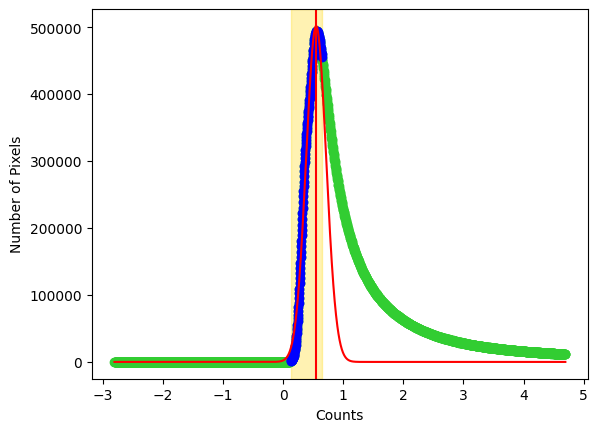

In [6]:

# img_f200,
# dust_mask,
# *,
pixel_scale=0.031,                 # arcsec/pix (only affects plot axes)
dust_mask_is_bad=True,           # True if your dust_mask marks dusty/bad pixels
subtract_sky=False,              # only use if your image is mostly sky (see note below)
find_fraction=0.03,              # fraction of brightest pixels used by find_galaxy
find_binning=5,
n_sectors=19,
minlevel=0,                      # stop profile when sector-mean <= minlevel
# PSF (optional): circular MGE in *pixels* (sigmapsf) with weights summing to 1 (normpsf)
sigmapsf=0.0,
normpsf=1.0,
# MGE fit controls
linear=True,                     # robust; recommended by mgefit docs
ngauss=400,                      # max allowed Gaussians (linear=True wants many)
qbounds=(0.05, 1.0),
outer_slope=4,
plot=True,
quiet=False
"""
Fit an MGE model to a 2D F200 image, excluding dusty pixels via a mask.

Returns a dict with:
    - geometry (center, pa, eps)
    - s: sectors_photometry object (radius, angle, counts)
    - m: fit_sectors object (m.sol = total_counts, sigma_pix, q_obs)
    - table: (surf, sigma_pix, sigma_arcsec, q_obs, total_counts)
"""
img = np.asarray(img_f200, dtype=float)
if img.ndim != 2:
    raise ValueError("img_f200 must be a 2D array")

mask = np.asarray(dust_mask)
if mask.shape != img.shape:
    raise ValueError("dust_mask must have the same shape as img_f200")
if mask.dtype != bool:
    mask = mask.astype(bool)

# mge.sectors_photometry expects mask=True for *good* pixels.
goodmask = (~mask) if dust_mask_is_bad else mask

# Basic sanity: no NaNs in the input image (mgefit routines assert this).
# For find_galaxy, replace masked (dusty) pixels with the median of unmasked pixels.
img_for_find = img.copy()
if np.any(goodmask):
    fill = np.nanmedian(img[goodmask])
else:
    fill = np.nanmedian(img)
img_for_find[~goodmask] = fill
if not np.all(np.isfinite(img_for_find)):
    raise ValueError("Image contains NaN/Inf even after filling masked pixels")

# Optional sky subtraction (only valid if most pixels are sky background)
sky_mean = None
sky_sigma = None
img_work = img.copy()
if subtract_sky:
    sky_mean, sky_sigma = mge.sky_level(img_for_find[goodmask], plot=plot, quiet=quiet)
    img_work = img_work - sky_mean
    img_for_find = img_for_find - sky_mean  # keep geometry consistent

# 1) Find galaxy geometry (center, PA, ellipticity)
f = mge.find_galaxy(
    img_for_find,
    fraction=find_fraction,
    binning=find_binning,
    plot=plot,
    quiet=quiet
)
# Note: xpeak/ypeak are numpy indices (row/col) in mgefit.
xc, yc = f.xpeak, f.ypeak
eps = f.eps
pa = f.pa  # astronomical PA, if your image is N-up



In [ ]:

# 2) Extract sector photometry using your dust mask
s = mge.sectors_photometry(
    img_work,
    eps=eps,
    ang=pa,
    xc=xc,
    yc=yc,
    mask=goodmask,
    n_sectors=n_sectors,
    minlevel=minlevel,
    plot=plot
)

# 3) Fit the MGE to the sector photometry
m = mge.fit_sectors(
    s.radius, s.angle, s.counts, eps,
    linear=linear,
    ngauss=ngauss,
    qbounds=qbounds,
    outer_slope=outer_slope,
    sigmapsf=sigmapsf,
    normpsf=normpsf,
    scale=pixel_scale,
    plot=plot,
    quiet=quiet
)

total_counts, sigma_pix, q_obs = m.sol  # mgefit convention

# Peak surface brightness (counts/pix) for each Gaussian:
# surf = total_counts / (2*pi*q_obs*sigma^2)
surf = total_counts / (2.0 * np.pi * q_obs * sigma_pix**2)
sigma_arcsec = sigma_pix * float(pixel_scale)

table = np.vstack([surf, sigma_pix, sigma_arcsec, q_obs, total_counts]).T

    # return {
    #     "center_pix": (xc, yc),
    #     "pa_deg": pa,
    #     "eps": eps,
    #     "sky_mean": sky_mean,
    #     "sky_sigma": sky_sigma,
    #     "sectors": s,
    #     "mgefit": m,
    #     "table_cols": ["surf_counts_per_pix", "sigma_pix", "sigma_arcsec", "q_obs", "total_counts"],
    #     "table": table,
    # }

# Check results of the mge

In [7]:
import pickle

# read pickled results from the mge_test.py script
with open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mge_fit_results.pkl', 'rb') as f:
    res = pickle.load(f)

In [8]:
res

{'center_pix': (7396, 7536),
 'pa_deg': 89.17063902269138,
 'eps': 0.751378115445491,
 'sky_mean': None,
 'sky_sigma': None,
 'sectors': <mgefit.sectors_photometry.sectors_photometry at 0x7fb871b27040>,
 'mgefit': <mgefit.mge_fit_sectors.mge_fit_sectors at 0x7fb8b0fea6a0>,
 'table_cols': ['surf_counts_per_pix',
  'sigma_pix',
  'sigma_arcsec',
  'q_obs',
  'total_counts'],
 'table': array([[1.47934728e+02, 2.82529860e+01, 8.75842565e-01, 1.00000000e+00,
         7.41956961e+05],
        [1.22854702e+02, 1.84020229e+02, 5.70462709e+00, 1.00000000e+00,
         2.61398315e+07],
        [2.00634429e+01, 5.43176168e+02, 1.68384612e+01, 1.00000000e+00,
         3.71934738e+07],
        [6.23151124e+00, 1.24483731e+03, 3.85899567e+01, 1.00000000e+00,
         6.06734159e+07],
        [1.32839122e+00, 4.01145315e+03, 1.24355047e+02, 1.00000000e+00,
         1.34310298e+08]])}

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# ----------------------------
# Helpers: model + coordinates
# ----------------------------
def _ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

def _stretch_for_display(img, goodmask=None):
    """
    Robust stretch for display (no assumptions about positivity).
    """
    x = np.asarray(img, float)
    if goodmask is None:
        goodmask = np.isfinite(x)

    v = x[goodmask]
    v = v[np.isfinite(v)]
    if v.size == 0:
        return x

    lo, hi = np.percentile(v, [5, 99.5])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return x

    z = np.clip(x, lo, hi)
    # asinh stretch
    z = np.arcsinh((z - lo) / (hi - lo + 1e-30))
    return z

def mge_model_counts_at_polar_points(radius_pix, angle_deg, sol):
    """
    Evaluate the *surface brightness* model (counts/pix) at the same polar points
    used in the MGE fit: (radius, angle) where angle is from the major axis.
    """
    total_counts, sigma, q = sol  # shapes (ngauss,)
    total_counts = np.asarray(total_counts, float)
    sigma = np.asarray(sigma, float)
    q = np.asarray(q, float)

    # peak surface brightness of each Gaussian
    surf = total_counts / (2.0 * np.pi * sigma**2 * q)

    th = np.deg2rad(np.asarray(angle_deg, float))
    r = np.asarray(radius_pix, float)
    x = r * np.cos(th)   # along major axis
    y = r * np.sin(th)   # along minor axis

    # Broadcast to (n_points, ngauss)
    xx = x[:, None]
    yy = y[:, None]
    sig2 = (sigma[None, :] ** 2)
    q2 = (q[None, :] ** 2)

    expo = -0.5 * (xx**2 + (yy**2) / q2) / sig2
    model = np.sum(surf[None, :] * np.exp(expo), axis=1)
    return model

def polar_points_to_image_xy(radius_pix, angle_deg, pa_deg, center_pix_rc):
    """
    Convert (radius, angle from major axis) into image coordinates (x,y) in pixels
    for overlay plots, using the MGEfit PA convention.

    center_pix_rc = (row, col) = (xc, yc) from your res["center_pix"].
    Returns arrays (x_img, y_img) with x=col, y=row in imshow(origin='lower').
    """
    xc_row, yc_col = center_pix_rc
    x0 = yc_col  # x-axis in imshow is column index
    y0 = xc_row  # y-axis in imshow is row index

    r = np.asarray(radius_pix, float)
    th = np.deg2rad(np.asarray(angle_deg, float))

    # galaxy frame: x' along major axis, y' along minor axis
    xp = r * np.cos(th)
    yp = r * np.sin(th)

    # PA is CCW from +Y (North) toward +X (East) in the display frame.
    pa = np.deg2rad(pa_deg)
    x_img = x0 + xp * np.sin(pa) + yp * np.cos(pa)
    y_img = y0 + xp * np.cos(pa) - yp * np.sin(pa)
    return x_img, y_img

def build_mge_model_image_cutout(img_shape, sol, pa_deg, center_pix_rc,
                                 half_size_pix=400, oversample=1):
    """
    Build a model image cutout (counts/pix) from the MGE solution.

    NOTE: this uses the *deconvolved* MGE solution if you supplied a PSF to fit_sectors.
    If you want a strict data-model comparison in that case, you'd want to reconvolve
    the model (analytically possible for circular PSF MGE, but omitted here for simplicity).
    """
    ny, nx = img_shape
    xc_row, yc_col = center_pix_rc
    x0 = float(yc_col)
    y0 = float(xc_row)

    # Cutout bounds (in full-res pixels)
    x1 = int(max(0, np.floor(x0 - half_size_pix)))
    x2 = int(min(nx, np.ceil(x0 + half_size_pix)))
    y1 = int(max(0, np.floor(y0 - half_size_pix)))
    y2 = int(min(ny, np.ceil(y0 + half_size_pix)))

    # Grid in pixel coordinates (x=col, y=row)
    xs = np.arange(x1, x2, 1/oversample)
    ys = np.arange(y1, y2, 1/oversample)
    X, Y = np.meshgrid(xs, ys)

    # Rotate into galaxy frame where x' is major axis
    pa = np.deg2rad(pa_deg)
    dx = X - x0
    dy = Y - y0
    xp =  dx * np.sin(pa) + dy * np.cos(pa)
    yp =  dx * np.cos(pa) - dy * np.sin(pa)

    total_counts, sigma, q = sol
    total_counts = np.asarray(total_counts, float)
    sigma = np.asarray(sigma, float)
    q = np.asarray(q, float)
    surf = total_counts / (2.0 * np.pi * sigma**2 * q)

    model = np.zeros_like(X, dtype=float)
    for s0, sj, qj in zip(surf, sigma, q):
        expo = -0.5 * (xp**2 + (yp**2) / (qj*qj)) / (sj*sj)
        model += s0 * np.exp(expo)

    # If oversampled, bin back to native pixels for comparison
    if oversample > 1:
        oy = (y2 - y1) * oversample
        ox = (x2 - x1) * oversample
        model = model[:oy, :ox]
        model = model.reshape((y2 - y1), oversample, (x2 - x1), oversample).mean(axis=(1, 3))

    return (x1, x2, y1, y2), model

# ----------------------------
# Main: generate checkplots
# ----------------------------
def save_mge_checkplots(
    img_f200,
    dust_mask,
    res,
    *,
    pixel_scale,                 # arcsec/pix
    outdir,
    prefix="f200",
    dust_mask_is_bad=True,
    find_fraction=0.03,
    find_binning=5,
    # display/plot controls
    max_points_overlay=200000,    # downsample photometry points if huge
    contour_half_size_arcsec=40,  # for model-vs-data contours cutout
    contour_oversample=1,
    dpi=600,
):
    """
    Saves a bunch of diagnostic plots into outdir.

    Expects:
      - img_f200: 2D array
      - dust_mask: same shape (True=bad/dust by default)
      - res: dict returned by your fit function (must contain center_pix, pa_deg, eps, sectors, mgefit)
    """
    _ensure_dir(outdir)

    img = np.asarray(img_f200, float)
    mask = np.asarray(dust_mask)
    if mask.dtype != bool:
        mask = mask.astype(bool)
    goodmask = (~mask) if dust_mask_is_bad else mask

    xc, yc = res["center_pix"]          # (row, col)
    pa = float(res["pa_deg"])
    eps = float(res["eps"])
    qbar = 1.0 - eps

    s = res["sectors"]
    m = res["mgefit"]

    # -------------------------
    # 1) Geometry overlay plot
    # -------------------------
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(_stretch_for_display(img, goodmask=goodmask), origin="lower")
    # mask outline
    try:
        ax.contour((~goodmask).astype(float), levels=[0.5], linewidths=0.8, alpha=0.8, origin="lower")
    except Exception:
        pass

    # Center (x=col, y=row)
    ax.plot([yc], [xc], marker="+", markersize=14)

    # Major axis line (a few arcsec)
    L_arcsec = 20.0
    L_pix = L_arcsec / pixel_scale
    pa_rad = np.deg2rad(pa)
    dx = L_pix * np.sin(pa_rad)
    dy = L_pix * np.cos(pa_rad)
    ax.plot([yc - dx, yc + dx], [xc - dy, xc + dy], linewidth=1.2)

    # Ellipses at a few semi-major radii (in arcsec)
    for a_arc in [5.0, 15.0, 30.0]:
        a_pix = a_arc / pixel_scale
        b_pix = a_pix * qbar
        e = Ellipse(
            (yc, xc), width=2*a_pix, height=2*b_pix,
            angle=(90.0 - pa), fill=False, linewidth=1.0
        )
        ax.add_patch(e)

    ax.set_title(f"{prefix}: geometry overlay  (PA={pa:.2f} deg, eps={eps:.3f})")
    ax.set_xlabel("x (pix)")
    ax.set_ylabel("y (pix)")
    fig.tight_layout()
    fig.savefig(os.path.join(outdir, f"{prefix}_01_geometry_overlay.png"), dpi=dpi)
    plt.close(fig)

    # -------------------------------------------------------
    # 2) Photometry sampling points (sectors visualization)
    # -------------------------------------------------------
    # Convert the sampled polar points back to image coordinates
    x_img, y_img = polar_points_to_image_xy(s.radius, s.angle, pa, (xc, yc))

    # Downsample if needed
    npts = x_img.size
    if npts > max_points_overlay:
        rng = np.random.default_rng(12345)
        idx = rng.choice(npts, size=max_points_overlay, replace=False)
    else:
        idx = slice(None)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(_stretch_for_display(img, goodmask=goodmask), origin="lower")
    try:
        ax.contour((~goodmask).astype(float), levels=[0.5], linewidths=0.8, alpha=0.8, origin="lower")
    except Exception:
        pass
    ax.scatter(x_img[idx], y_img[idx], s=1, alpha=0.4)  # sampled points
    ax.plot([yc], [xc], marker="+", markersize=14)
    ax.set_title(f"{prefix}: sampled photometry points (sectors)")
    ax.set_xlabel("x (pix)")
    ax.set_ylabel("y (pix)")
    fig.tight_layout()
    fig.savefig(os.path.join(outdir, f"{prefix}_02_sectors_sampled_points.png"), dpi=dpi)
    plt.close(fig)

    # -------------------------------------------------------
    # 3) Sector-by-sector radial profiles (data only)
    # -------------------------------------------------------
    r_arc = np.asarray(s.radius) * pixel_scale
    y_dat = np.asarray(s.counts)

    # group by discrete angles (sectors_photometry gives repeated values)
    ang = np.asarray(s.angle)
    uniq = np.unique(np.round(ang, 6))

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    for a in uniq:
        sel = np.isclose(ang, a)
        rr = r_arc[sel]
        yy = y_dat[sel]
        o = np.argsort(rr)
        rr, yy = rr[o], yy[o]
        ax.plot(rr, yy, linewidth=0.8, alpha=0.5)

    if np.all(y_dat[y_dat > 0] > 0):
        ax.set_yscale("log")

    ax.set_xlabel("R (arcsec)")
    ax.set_ylabel("counts / pix")
    ax.set_title(f"{prefix}: sector radial profiles (data)")
    fig.tight_layout()
    fig.savefig(os.path.join(outdir, f"{prefix}_03_sector_profiles.png"), dpi=dpi)
    plt.close(fig)

    # -------------------------------------------------------
    # 4) Data vs model radial profile (all points) + model axes
    # -------------------------------------------------------
    y_mod_pts = mge_model_counts_at_polar_points(s.radius, s.angle, m.sol)
    # model along major/minor axis for a smooth reference
    rmin = max(np.nanmin(s.radius[s.radius > 0]), 0.5)
    rmax = np.nanmax(s.radius)
    rgrid = np.geomspace(rmin, rmax, 250)
    rgrid_arc = rgrid * pixel_scale

    y_major = mge_model_counts_at_polar_points(rgrid, np.zeros_like(rgrid), m.sol)
    y_minor = mge_model_counts_at_polar_points(rgrid, np.full_like(rgrid, 90.0), m.sol)
    y_45    = mge_model_counts_at_polar_points(rgrid, np.full_like(rgrid, 45.0), m.sol)

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    ax.scatter(r_arc, y_dat, s=6, alpha=0.35, label="data (all sectors)")
    ax.plot(rgrid_arc, y_major, linewidth=1.8, label="model (major axis)")
    ax.plot(rgrid_arc, y_minor, linewidth=1.8, label="model (minor axis)")
    ax.plot(rgrid_arc, y_45,    linewidth=1.2, label="model (45 deg)")
    ax.set_xlabel("R (arcsec)")
    ax.set_ylabel("counts / pix")
    # log scale if it makes sense
    if np.nanmin(y_dat[y_dat > 0]) > 0:
        ax.set_yscale("log")
    ax.set_title(f"{prefix}: radial profile data vs model  (absdev={m.absdev:.4f})")
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(os.path.join(outdir, f"{prefix}_04_radial_profile_data_vs_model.png"), dpi=dpi)
    plt.close(fig)

    # -------------------------------------------------------
    # 5) Fractional residual: 1 - yfit/y vs radius
    # -------------------------------------------------------
    good = np.isfinite(y_dat) & np.isfinite(y_mod_pts) & (y_dat != 0)
    frac = np.full_like(y_dat, np.nan, dtype=float)
    frac[good] = 1.0 - (y_mod_pts[good] / y_dat[good])

    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    ax.scatter(r_arc[good], frac[good], s=6, alpha=0.35)
    ax.axhline(0.0, linewidth=1.0)
    ax.set_xlabel("R (arcsec)")
    ax.set_ylabel(r"$1 - y_{\rm fit}/y$")
    ax.set_title(f"{prefix}: fractional residuals")
    fig.tight_layout()
    fig.savefig(os.path.join(outdir, f"{prefix}_05_frac_residual_1_minus_yfit_over_y.png"), dpi=dpi)
    plt.close(fig)

    # -------------------------------------------------------
    # 6) Data vs model contours (cutout)
    # -------------------------------------------------------
    half_size_pix = int(max(10, contour_half_size_arcsec / pixel_scale))
    bounds, model_cut = build_mge_model_image_cutout(
        img.shape, m.sol, pa, (xc, yc),
        half_size_pix=half_size_pix,
        oversample=contour_oversample,
    )
    x1, x2, y1, y2 = bounds
    data_cut = img[y1:y2, x1:x2]
    good_cut = goodmask[y1:y2, x1:x2]

    # Choose contour levels from the data cutout (robust)
    v = data_cut[good_cut]
    v = v[np.isfinite(v)]
    if v.size > 0:
        levels = np.percentile(v, [70, 80, 90, 95, 97, 99])
        levels = np.unique(levels[np.isfinite(levels)])
        if levels.size >= 3:
            fig, ax = plt.subplots(figsize=(7, 7))
            ax.imshow(_stretch_for_display(data_cut, goodmask=good_cut), origin="lower",
                      extent=[x1, x2, y1, y2])
            ax.contour(model_cut, levels=levels, linewidths=1.0,
                       origin="lower", extent=[x1, x2, y1, y2])
            ax.plot([yc], [xc], marker="+", markersize=14)
            ax.set_title(f"{prefix}: model contours over data (cutout)")
            ax.set_xlabel("x (pix)")
            ax.set_ylabel("y (pix)")
            fig.tight_layout()
            fig.savefig(os.path.join(outdir, f"{prefix}_06_model_contours_over_data.png"), dpi=dpi)
            plt.close(fig)

            # residual image (data/model)
            fig, ax = plt.subplots(figsize=(7, 7))
            with np.errstate(divide="ignore", invalid="ignore"):
                ratio = data_cut / model_cut
            ax.imshow(_stretch_for_display(ratio, goodmask=good_cut), origin="lower",
                      extent=[x1, x2, y1, y2])
            ax.plot([yc], [xc], marker="+", markersize=14)
            ax.set_title(f"{prefix}: data/model ratio (cutout)")
            ax.set_xlabel("x (pix)")
            ax.set_ylabel("y (pix)")
            fig.tight_layout()
            fig.savefig(os.path.join(outdir, f"{prefix}_07_data_over_model_ratio.png"), dpi=dpi)
            plt.close(fig)

    # Done
    print(f"Saved checkplots to: {outdir}")
    return outdir

In [10]:
save_mge_checkplots(
    img_f200, dust_mask, res,
    pixel_scale=0.031,
    outdir="/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Results/MGE_checkplots",
    prefix="f200",
    dust_mask_is_bad=True,
    find_fraction=0.03,
    find_binning=5,
    max_points_overlay=200000,
    contour_half_size_arcsec=40,
    contour_oversample=1,
    dpi=600,
)

Saved checkplots to: /Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Results/MGE_checkplots


'/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Results/MGE_checkplots'

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import mgefit as mge


# ----------------------------
# Helpers: model + coordinates
# ----------------------------
def _ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

def _stretch_for_display(img, goodmask=None):
    """Robust stretch for display (no assumptions about positivity)."""
    x = np.asarray(img, float)
    if goodmask is None:
        goodmask = np.isfinite(x)

    v = x[goodmask]
    v = v[np.isfinite(v)]
    if v.size == 0:
        return x

    lo, hi = np.percentile(v, [5, 99.5])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return x

    z = np.clip(x, lo, hi)
    z = np.arcsinh((z - lo) / (hi - lo + 1e-30))
    return z

def _capture_new_figures(callable_fn):
    """
    Run callable_fn() which may create matplotlib figures. Return list of new figure numbers.
    """
    before = set(plt.get_fignums())
    out = callable_fn()
    after = set(plt.get_fignums())
    new = sorted(list(after - before))
    return out, new

def _save_and_close_figs(fig_nums, outpaths, dpi=200):
    for fn, path in zip(fig_nums, outpaths):
        fig = plt.figure(fn)
        fig.savefig(path, dpi=dpi)
        plt.close(fig)

def mge_model_counts_at_polar_points(radius_pix, angle_deg, sol):
    """
    Evaluate the *surface brightness* model (counts/pix) at the same polar points
    used in the MGE fit: (radius, angle) where angle is from the major axis.
    """
    total_counts, sigma, q = sol
    total_counts = np.asarray(total_counts, float)
    sigma = np.asarray(sigma, float)
    q = np.asarray(q, float)

    surf = total_counts / (2.0 * np.pi * sigma**2 * q)

    th = np.deg2rad(np.asarray(angle_deg, float))
    r = np.asarray(radius_pix, float)
    x = r * np.cos(th)
    y = r * np.sin(th)

    xx = x[:, None]
    yy = y[:, None]
    sig2 = (sigma[None, :] ** 2)
    q2 = (q[None, :] ** 2)

    expo = -0.5 * (xx**2 + (yy**2) / q2) / sig2
    model = np.sum(surf[None, :] * np.exp(expo), axis=1)
    return model

def polar_points_to_image_xy(radius_pix, angle_deg, pa_deg, center_pix_rc):
    """
    Convert (radius, angle from major axis) into image coordinates (x,y) in pixels
    for overlay plots, using the MGEfit PA convention.

    center_pix_rc = (row, col) = (xc, yc) from your res["center_pix"].
    Returns (x_img, y_img) with x=col and y=row for imshow(origin='lower').
    """
    xc_row, yc_col = center_pix_rc
    x0 = yc_col
    y0 = xc_row

    r = np.asarray(radius_pix, float)
    th = np.deg2rad(np.asarray(angle_deg, float))

    xp = r * np.cos(th)
    yp = r * np.sin(th)

    pa = np.deg2rad(pa_deg)
    x_img = x0 + xp * np.sin(pa) + yp * np.cos(pa)
    y_img = y0 + xp * np.cos(pa) - yp * np.sin(pa)
    return x_img, y_img

def build_mge_model_image_cutout(img_shape, sol, pa_deg, center_pix_rc,
                                 half_size_pix=400, oversample=1):
    """
    Build a model image cutout (counts/pix) from the MGE solution.

    NOTE: If you supplied a PSF to fit_sectors, sol is deconvolved; a strict
    data-model comparison would want the model reconvolved with the PSF.
    """
    ny, nx = img_shape
    xc_row, yc_col = center_pix_rc
    x0 = float(yc_col)
    y0 = float(xc_row)

    x1 = int(max(0, np.floor(x0 - half_size_pix)))
    x2 = int(min(nx, np.ceil(x0 + half_size_pix)))
    y1 = int(max(0, np.floor(y0 - half_size_pix)))
    y2 = int(min(ny, np.ceil(y0 + half_size_pix)))

    xs = np.arange(x1, x2, 1/oversample)
    ys = np.arange(y1, y2, 1/oversample)
    X, Y = np.meshgrid(xs, ys)

    pa = np.deg2rad(pa_deg)
    dx = X - x0
    dy = Y - y0
    xp =  dx * np.sin(pa) + dy * np.cos(pa)
    yp =  dx * np.cos(pa) - dy * np.sin(pa)

    total_counts, sigma, q = sol
    total_counts = np.asarray(total_counts, float)
    sigma = np.asarray(sigma, float)
    q = np.asarray(q, float)
    surf = total_counts / (2.0 * np.pi * sigma**2 * q)

    model = np.zeros_like(X, dtype=float)
    for s0, sj, qj in zip(surf, sigma, q):
        expo = -0.5 * (xp**2 + (yp**2) / (qj*qj)) / (sj*sj)
        model += s0 * np.exp(expo)

    if oversample > 1:
        oy = (y2 - y1) * oversample
        ox = (x2 - x1) * oversample
        model = model[:oy, :ox]
        model = model.reshape((y2 - y1), oversample, (x2 - x1), oversample).mean(axis=(1, 3))

    return (x1, x2, y1, y2), model


# ----------------------------
# Main: generate checkplots
# ----------------------------
def save_mge_checkplots(
    img_f200,
    dust_mask,
    res,
    *,
    pixel_scale,                 # arcsec/pix
    outdir,
    prefix="f200",
    dust_mask_is_bad=True,
    # to reproduce mge.find_galaxy(plot=True)
    find_fraction=0.03,
    find_binning=5,
    find_quiet=True,
    save_find_galaxy_diagnostic=True,
    # display/plot controls
    max_points_overlay=200000,
    contour_half_size_arcsec=40,
    contour_oversample=1,
    dpi=200,
):
    """
    Saves diagnostics into outdir, including the native find_galaxy(plot=True) diagnostic view.
    Expects res to contain: center_pix, pa_deg, eps, sectors, mgefit, and optionally sky_mean.
    """
    _ensure_dir(outdir)

    img = np.asarray(img_f200, float)
    mask = np.asarray(dust_mask)
    if mask.dtype != bool:
        mask = mask.astype(bool)
    goodmask = (~mask) if dust_mask_is_bad else mask

    xc, yc = res["center_pix"]  # (row, col)
    pa = float(res["pa_deg"])
    eps = float(res["eps"])
    qbar = 1.0 - eps

    s = res["sectors"]
    m = res["mgefit"]

    # -------------------------------------------------------
    # 0) Native mge.find_galaxy(plot=True) diagnostic view
    # -------------------------------------------------------
    if save_find_galaxy_diagnostic:
        # Rebuild the same "img_for_find" logic you used in the fitting function
        img_for_find = img.copy()

        fill = np.nanmedian(img[goodmask]) if np.any(goodmask) else np.nanmedian(img)
        img_for_find[~goodmask] = fill

        # If sky was subtracted in your fit, apply it here so the diagnostic matches
        if res.get("sky_mean", None) is not None:
            img_for_find = img_for_find - float(res["sky_mean"])

        # Capture the figure(s) created by find_galaxy(plot=True)
        def _do_find():
            return mge.find_galaxy(
                img_for_find,
                fraction=find_fraction,
                binning=find_binning,
                plot=True,
                quiet=find_quiet
            )

        fdiag, new_figs = _capture_new_figures(_do_find)

        if len(new_figs) == 0:
            # Some matplotlib states can reuse an existing figure; just save gcf
            fig = plt.gcf()
            fig.savefig(os.path.join(outdir, f"{prefix}_00_find_galaxy_diagnostic.png"), dpi=dpi)
            plt.close(fig)
        else:
            # Save all new figures (usually one)
            paths = [
                os.path.join(outdir, f"{prefix}_00_find_galaxy_diagnostic_{i+1:02d}.png")
                for i in range(len(new_figs))
            ]
            _save_and_close_figs(new_figs, paths, dpi=dpi)

    # -------------------------
    # 1) Geometry overlay plot
    # -------------------------
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(_stretch_for_display(img, goodmask=goodmask), origin="lower")
    try:
        ax.contour((~goodmask).astype(float), levels=[0.5], linewidths=0.8, alpha=0.8, origin="lower")
    except Exception:
        pass

    ax.plot([yc], [xc], marker="+", markersize=14)

    L_arcsec = 20.0
    L_pix = L_arcsec / pixel_scale
    pa_rad = np.deg2rad(pa)
    dx = L_pix * np.sin(pa_rad)
    dy = L_pix * np.cos(pa_rad)
    ax.plot([yc - dx, yc + dx], [xc - dy, xc + dy], linewidth=1.2)

    for a_arc in [5.0, 15.0, 30.0]:
        a_pix = a_arc / pixel_scale
        b_pix = a_pix * qbar
        e = Ellipse(
            (yc, xc), width=2*a_pix, height=2*b_pix,
            angle=(90.0 - pa), fill=False, linewidth=1.0
        )
        ax.add_patch(e)

    ax.set_title(f"{prefix}: geometry overlay  (PA={pa:.2f} deg, eps={eps:.3f})")
    ax.set_xlabel("x (pix)")
    ax.set_ylabel("y (pix)")
    fig.tight_layout()
    fig.savefig(os.path.join(outdir, f"{prefix}_01_geometry_overlay.png"), dpi=dpi)
    plt.close(fig)

    # -------------------------------------------------------
    # 2) Photometry sampling points (sectors visualization)
    # -------------------------------------------------------
    x_img, y_img = polar_points_to_image_xy(s.radius, s.angle, pa, (xc, yc))

    npts = x_img.size
    if npts > max_points_overlay:
        rng = np.random.default_rng(12345)
        idx = rng.choice(npts, size=max_points_overlay, replace=False)
    else:
        idx = slice(None)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(_stretch_for_display(img, goodmask=goodmask), origin="lower")
    try:
        ax.contour((~goodmask).astype(float), levels=[0.5], linewidths=0.8, alpha=0.8, origin="lower")
    except Exception:
        pass
    ax.scatter(x_img[idx], y_img[idx], s=1, alpha=0.4)
    ax.plot([yc], [xc], marker="+", markersize=14)
    ax.set_title(f"{prefix}: sampled photometry points (sectors)")
    ax.set_xlabel("x (pix)")
    ax.set_ylabel("y (pix)")
    fig.tight_layout()
    fig.savefig(os.path.join(outdir, f"{prefix}_02_sectors_sampled_points.png"), dpi=dpi)
    plt.close(fig)

    # -------------------------------------------------------
    # 3) Sector-by-sector radial profiles (data only)
    # -------------------------------------------------------
    r_arc = np.asarray(s.radius) * pixel_scale
    y_dat = np.asarray(s.counts)

    ang = np.asarray(s.angle)
    uniq = np.unique(np.round(ang, 6))

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    for a in uniq:
        sel = np.isclose(ang, a)
        rr = r_arc[sel]
        yy = y_dat[sel]
        o = np.argsort(rr)
        rr, yy = rr[o], yy[o]
        ax.plot(rr, yy, linewidth=0.8, alpha=0.5)

    if np.nanmin(y_dat[y_dat > 0]) > 0:
        ax.set_yscale("log")

    ax.set_xlabel("R (arcsec)")
    ax.set_ylabel("counts / pix")
    ax.set_title(f"{prefix}: sector radial profiles (data)")
    fig.tight_layout()
    fig.savefig(os.path.join(outdir, f"{prefix}_03_sector_profiles.png"), dpi=dpi)
    plt.close(fig)

    # -------------------------------------------------------
    # 4) Data vs model radial profile (all points) + model axes
    # -------------------------------------------------------
    y_mod_pts = mge_model_counts_at_polar_points(s.radius, s.angle, m.sol)

    rpos = np.asarray(s.radius)
    rpos = rpos[np.isfinite(rpos) & (rpos > 0)]
    rmin = max(np.nanmin(rpos), 0.5) if rpos.size else 0.5
    rmax = np.nanmax(s.radius)
    rgrid = np.geomspace(rmin, rmax, 250)
    rgrid_arc = rgrid * pixel_scale

    y_major = mge_model_counts_at_polar_points(rgrid, np.zeros_like(rgrid), m.sol)
    y_minor = mge_model_counts_at_polar_points(rgrid, np.full_like(rgrid, 90.0), m.sol)
    y_45    = mge_model_counts_at_polar_points(rgrid, np.full_like(rgrid, 45.0), m.sol)

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    ax.scatter(r_arc, y_dat, s=6, alpha=0.35, label="data (all sectors)")
    ax.plot(rgrid_arc, y_major, linewidth=1.8, label="model (major axis)")
    ax.plot(rgrid_arc, y_minor, linewidth=1.8, label="model (minor axis)")
    ax.plot(rgrid_arc, y_45,    linewidth=1.2, label="model (45 deg)")
    ax.set_xlabel("R (arcsec)")
    ax.set_ylabel("counts / pix")
    if np.nanmin(y_dat[y_dat > 0]) > 0:
        ax.set_yscale("log")
    ax.set_title(f"{prefix}: radial profile data vs model  (absdev={m.absdev:.4f})")
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(os.path.join(outdir, f"{prefix}_04_radial_profile_data_vs_model.png"), dpi=dpi)
    plt.close(fig)

    # -------------------------------------------------------
    # 5) Fractional residual: 1 - yfit/y vs radius
    # -------------------------------------------------------
    good = np.isfinite(y_dat) & np.isfinite(y_mod_pts) & (y_dat != 0)
    frac = np.full_like(y_dat, np.nan, dtype=float)
    frac[good] = 1.0 - (y_mod_pts[good] / y_dat[good])

    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    ax.scatter(r_arc[good], frac[good], s=6, alpha=0.35)
    ax.axhline(0.0, linewidth=1.0)
    ax.set_xlabel("R (arcsec)")
    ax.set_ylabel(r"$1 - y_{\rm fit}/y$")
    ax.set_title(f"{prefix}: fractional residuals")
    fig.tight_layout()
    fig.savefig(os.path.join(outdir, f"{prefix}_05_frac_residual_1_minus_yfit_over_y.png"), dpi=dpi)
    plt.close(fig)

    # -------------------------------------------------------
    # 6) Data vs model contours (cutout) + data/model ratio
    # -------------------------------------------------------
    half_size_pix = int(max(10, contour_half_size_arcsec / pixel_scale))
    bounds, model_cut = build_mge_model_image_cutout(
        img.shape, m.sol, pa, (xc, yc),
        half_size_pix=half_size_pix,
        oversample=contour_oversample,
    )
    x1, x2, y1, y2 = bounds
    data_cut = img[y1:y2, x1:x2]
    good_cut = goodmask[y1:y2, x1:x2]

    v = data_cut[good_cut]
    v = v[np.isfinite(v)]
    if v.size > 0:
        levels = np.percentile(v, [70, 80, 90, 95, 97, 99])
        levels = np.unique(levels[np.isfinite(levels)])
        if levels.size >= 3:
            fig, ax = plt.subplots(figsize=(7, 7))
            ax.imshow(_stretch_for_display(data_cut, goodmask=good_cut), origin="lower",
                      extent=[x1, x2, y1, y2])
            ax.contour(model_cut, levels=levels, linewidths=1.0,
                       origin="lower", extent=[x1, x2, y1, y2])
            ax.plot([yc], [xc], marker="+", markersize=14)
            ax.set_title(f"{prefix}: model contours over data (cutout)")
            ax.set_xlabel("x (pix)")
            ax.set_ylabel("y (pix)")
            fig.tight_layout()
            fig.savefig(os.path.join(outdir, f"{prefix}_06_model_contours_over_data.png"), dpi=dpi)
            plt.close(fig)

            fig, ax = plt.subplots(figsize=(7, 7))
            with np.errstate(divide="ignore", invalid="ignore"):
                ratio = data_cut / model_cut
            ax.imshow(_stretch_for_display(ratio, goodmask=good_cut), origin="lower",
                      extent=[x1, x2, y1, y2])
            ax.plot([yc], [xc], marker="+", markersize=14)
            ax.set_title(f"{prefix}: data/model ratio (cutout)")
            ax.set_xlabel("x (pix)")
            ax.set_ylabel("y (pix)")
            fig.tight_layout()
            fig.savefig(os.path.join(outdir, f"{prefix}_07_data_over_model_ratio.png"), dpi=dpi)
            plt.close(fig)

    print(f"Saved checkplots to: {outdir}")
    return outdir

In [ ]:
checkplot_dir = "/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mge_checkplots"

save_mge_checkplots(
    img_f200,
    dust_mask,
    res,
    pixel_scale=0.031,
    outdir=checkplot_dir,
    prefix="sombrero_f200",
    dust_mask_is_bad=True,
    find_fraction=0.03,
    find_binning=5,
    save_find_galaxy_diagnostic=True,
    contour_half_size_arcsec=80,
    contour_oversample=1,
)

Saved checkplots to: /Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mge_checkplots


'/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mge_checkplots'

: 